# **WEEK 7**
Dimensionality Reduction. Implementing Feature Selection and PCA. Visualizing variance.

# **Dimensionality Reduction:**

Dimensionality reduction is the process of reducing the number of features (variables) in a dataset while retaining the most important information. Large datasets often contain redundant or irrelevant features, which can increase computational complexity and reduce model performance.
By reducing the number of features, dimensionality reduction helps:

Improve model efficiency
Reduce overfitting
Simplify visualization
Remove redundant features

Two commonly used techniques are:

Feature Selection
Principal Component Analysis (PCA)
By reducing the number of features, dimensionality reduction helps:

Improve model efficiency
Reduce overfitting
Simplify visualization
Remove redundant features

Two commonly used techniques are:

Feature Selection

Principal Component Analysis (PCA)

**Feature Selection:**

Feature selection identifies the most important variables in a dataset and removes irrelevant or redundant features.

Common feature selection techniques include:

Correlation-based selection
Variance threshold
SelectKBest
Recursive Feature Elimination (RFE)

# **Feature Selection using Correlation**

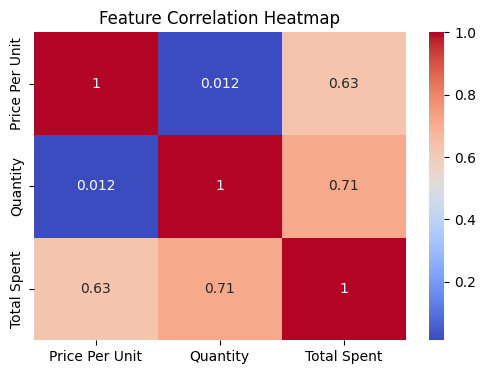

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/retail_store_sales.csv")

# Select numeric features
numeric_df = df[['Price Per Unit','Quantity','Total Spent']]

# Compute correlation
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

Visualization Explanation:

The correlation heatmap shows the relationship between numerical variables.

Interpretation:

Values close to 1 indicate strong positive correlation
Values close to 0 indicate weak relationship
Values close to -1 indicate strong negative correlation

For example:

Quantity and Total Spent may have strong correlation because purchasing more items increases spending.

This helps us determine which features are important for prediction.

# **Feature Selection using Variance Threshold**:

Features with very low variance contain little information and can be removed.

In [2]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
selected_features = selector.fit_transform(numeric_df)
print(selected_features)

[[ 18.5  10.  185. ]
 [ 29.    9.  261. ]
 [ 21.5   2.   43. ]
 ...
 [ 14.   10.  140. ]
 [ 14.    6.   84. ]
 [ 17.    3.   51. ]]


**Explanation**:

Variance threshold removes features that do not change much across observations.

Low variance features are not useful for machine learning models.

# **Feature Importance (Using Random Forest)**

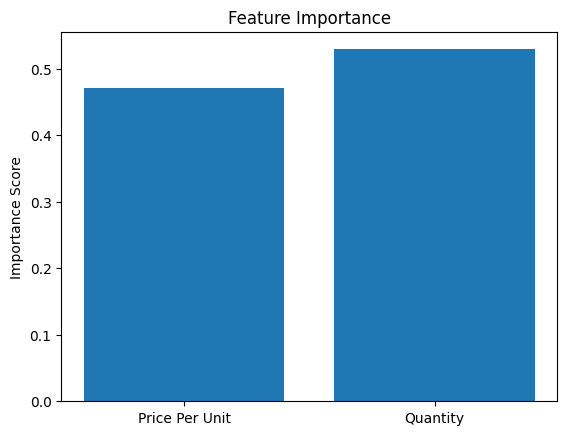

In [5]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Drop rows with NaN values in 'Total Spent' before splitting X and y
df_cleaned = df.dropna(subset=['Total Spent'])

X = df_cleaned[['Price Per Unit','Quantity']]
y = df_cleaned['Total Spent']

model = RandomForestRegressor()
model.fit(X, y)
importance = model.feature_importances_
plt.bar(X.columns, importance)
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()

# **Explanation**

This graph shows which features contribute the most to predicting the target variable.
Higher importance values indicate more influential features.

# **Variance of Features**

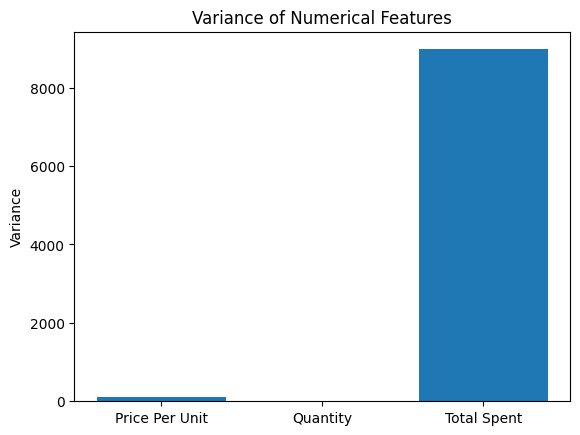

In [6]:
variances = numeric_df.var()

plt.bar(variances.index, variances.values)
plt.title("Variance of Numerical Features")
plt.ylabel("Variance")
plt.show()

**Explanation:**

Features with very low variance contain little useful information.
Such features may be removed during feature selection

# **Pair Plot (Relationship Visualization)**

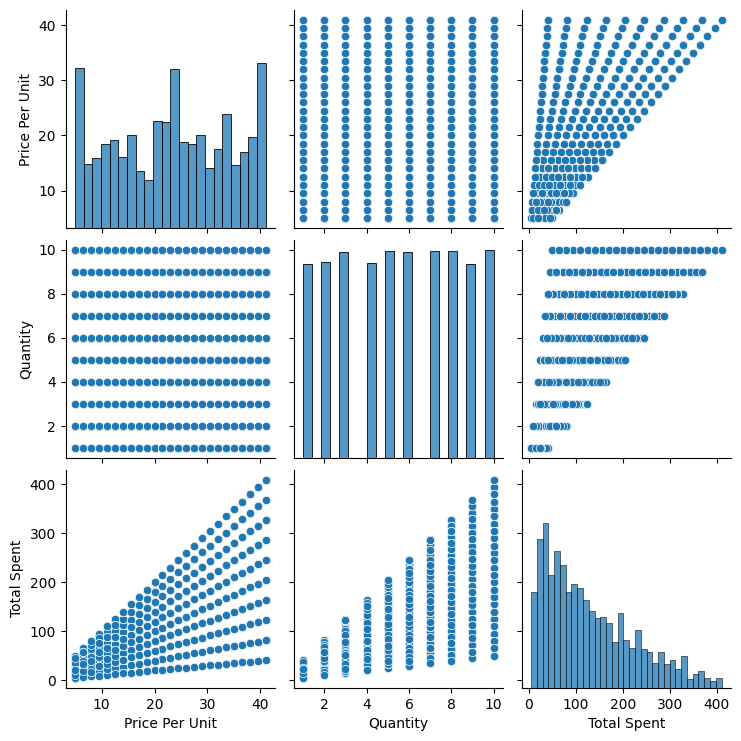

In [7]:
sns.pairplot(numeric_df)
plt.show()

**Explanation**:

The pair plot visualizes relationships between every pair of variables.
It helps identify patterns, clusters, and correlations among features.

# **Box Plot Comparison**

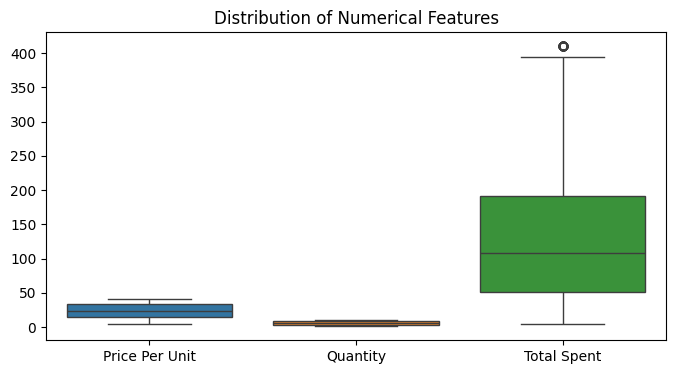

In [8]:
plt.figure(figsize=(8,4))

sns.boxplot(data=numeric_df)

plt.title("Distribution of Numerical Features")
plt.show()

**Explanation**

Boxplots help analyze feature distributions and detect outliers that may affect feature selection.

# **Scatter Plot Matrix (Alternative to Pair Plot)**

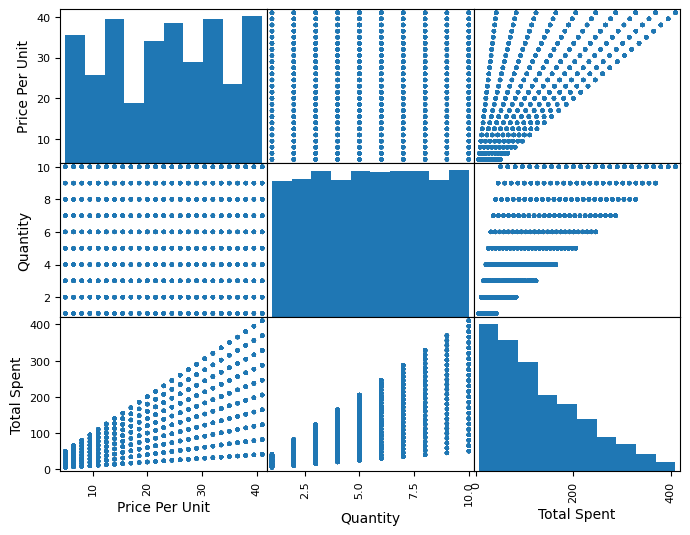

In [9]:
pd.plotting.scatter_matrix(numeric_df, figsize=(8,6))
plt.show()

# **Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the original variables into new uncorrelated variables called principal components.

Each principal component captures maximum variance in the dataset.

Key advantages:

Reduces dimensionality
Removes multicollinearity
Improves model efficiency

**Step 1 Standardize the Data:**


PCA works best when features are standardized.

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

**Explanation:**

Standardization ensures that all features have:

Mean = 0
Standard deviation = 1

This prevents variables with larger values from dominating PCA.

**Step 2 Apply PCA**

In [12]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()

# Identify rows with NaN values in scaled_data
nan_rows_mask = np.isnan(scaled_data).any(axis=1)

# Remove rows with NaN values before applying PCA
scaled_data_cleaned = scaled_data[~nan_rows_mask]

pca_data = pca.fit_transform(scaled_data_cleaned)

**Explanation**:


PCA transforms the dataset into principal components.

Each component represents a combination of original features.

# **Step 3 Visualizing Explained Variance**:

Explained variance shows how much information each principal component retains.

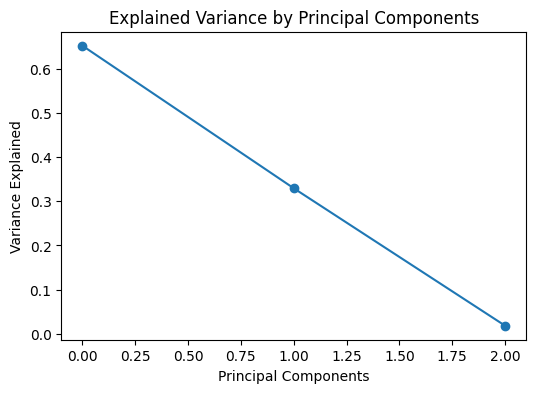

In [13]:
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(6,4))

plt.plot(explained_variance, marker='o')

plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")

plt.show()

Visualization Explanation:
**bold text**
This graph shows how much variance is captured by each principal component.

Interpretation example:

PC1 might explain 60% of variance
PC2 might explain 30% of variance

This means that two components capture most of the dataset information

# **PCA Scatter Plot Visualization**:

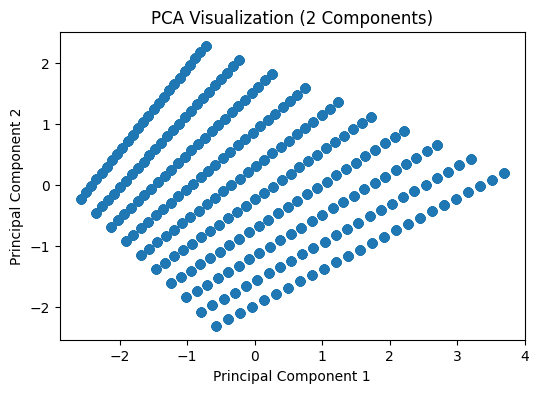

In [15]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data_cleaned)

plt.figure(figsize=(6,4))

plt.scatter(pca_result[:,0], pca_result[:,1])

plt.title("PCA Visualization (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

**Visualization Explanation:**

The scatter plot shows the dataset projected onto two principal components.

Interpretation:

Points close together represent similar data patterns
PCA simplifies high-dimensional data into 2D visualization

This makes complex datasets easier to analyze.

# **Explained Variance Plot:**

This graph shows how much variance each principal component captures.

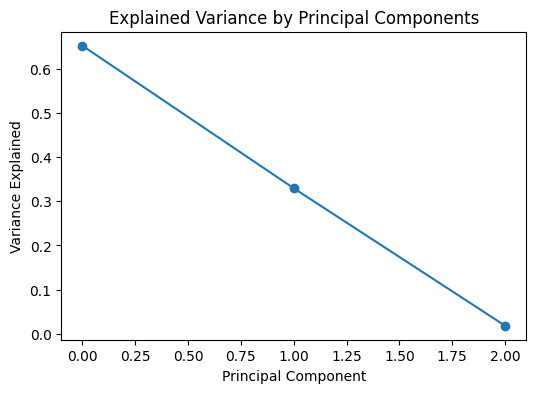

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

numeric_df = df[['Price Per Unit','Quantity','Total Spent']]

# Standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Apply PCA
pca = PCA()
pca_data = pca.fit_transform(scaled_data_cleaned)

# Explained variance
plt.figure(figsize=(6,4))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Explained Variance by Principal Components")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.show()

**Explanation:**

This plot shows how much information each principal component captures.
If the first two components explain most of the variance, then the dataset can be reduced to two dimensions without losing much information.

**Cumulative Variance Plot:**

Shows the total variance captured as we add more principal components.

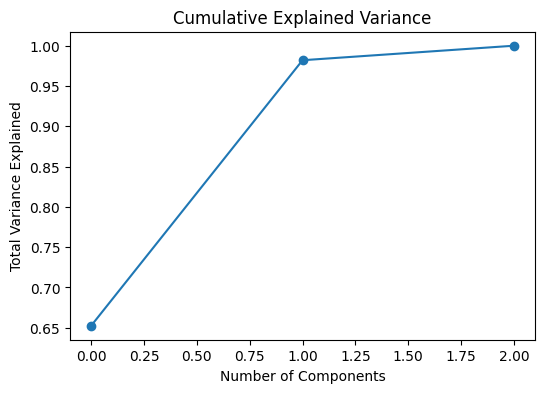

In [18]:
import numpy as np
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Total Variance Explained")
plt.show()

**Explanation:**

This graph helps determine the optimal number of principal components.
For example, if two components capture 90% of the variance, we can reduce the dataset to two dimensions.

**PCA Scatter Plot (2D Projection):**


Projects the dataset into two principal components.

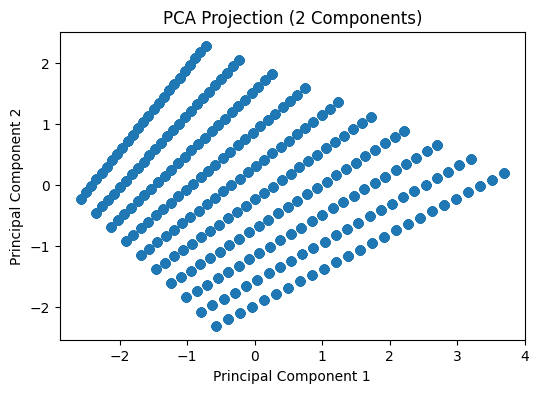

In [20]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data_cleaned)

plt.figure(figsize=(6,4))
plt.scatter(pca_result[:,0], pca_result[:,1])

plt.title("PCA Projection (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

**Explanation**

This visualization shows how data points are distributed after dimensionality reduction.
Points that are close together represent similar observations.

**PCA Loading Plot**

Shows how each original feature contributes to the principal components.

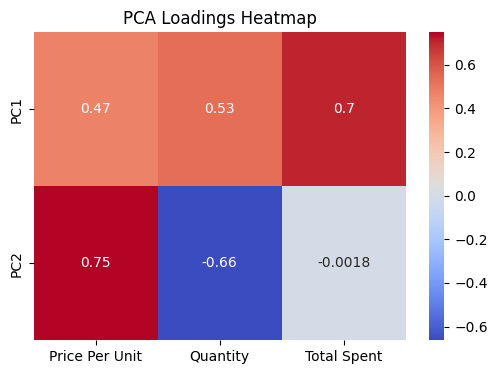

In [21]:
loadings = pca.components_

plt.figure(figsize=(6,4))
sns.heatmap(loadings, annot=True, cmap='coolwarm',
            yticklabels=['PC1','PC2'],
            xticklabels=numeric_df.columns)

plt.title("PCA Loadings Heatmap")
plt.show()

**Explanation:**

The loading heatmap shows the influence of each feature on each principal component.
Higher absolute values indicate stronger contributions.

**Scree Plot:**

A scree plot is another way to visualize explained variance.

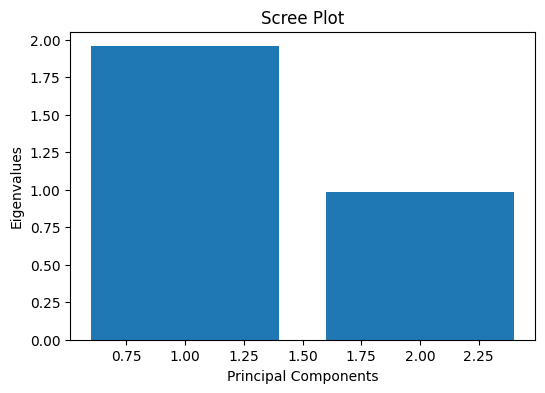

In [22]:
plt.figure(figsize=(6,4))
plt.bar(range(1,len(pca.explained_variance_)+1),
        pca.explained_variance_)

plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Eigenvalues")
plt.show()

**Explanation:**


The scree plot shows the eigenvalues of each component.
The point where the slope flattens (the elbow) indicates the number of components to retain

# **FINAL SUMMARY:**

Dimensionality reduction helps simplify datasets by reducing the number of variables while preserving important information. In this stage, feature selection methods were used to identify the most relevant variables by analyzing correlations and removing low-variance features. Principal Component Analysis (PCA) was then applied to transform the dataset into a smaller set of uncorrelated components that capture the maximum variance. Visualization of explained variance helped determine how many principal components were needed to represent the dataset effectively. By reducing the dimensionality of the data, computational efficiency improves and machine learning models can perform more accurately with reduced risk of overfitting.